# Notebook 08: Trend Analysis & Development Ranking

**SignalBrief: Multi-Factor Relevance, Exponential Recency Decay, Multi-Source Boost, and Development Selection**

---

### Section 1: Title, Project Context & Objectives
In this eighth stage of the SignalBrief research pipeline, we evaluate and rank thematic clusters from Stage 07 (`data/processed/topic_clusters_manufacturing.json`) to select the **top 3 to 5 core developments** for today's executive intelligence brief.

**Alignment with Product Promise**:
Our users need to know *what changed* and *why it matters*. Delivering an undifferentiated list of 70 articles causes cognitive overload. A rigorous, deterministic ranking formula ensures that the brief presents only the most relevant, timely, and credible developments.



### Section 2: Learning & Business Objectives
- **Business Objective**: Select the top 5 high-impact industrial developments for inclusion in the daily one-page brief using an objective, explainable scoring model.
- **Learning Objective**: Master mathematical recency decay modeling ($e^{-\lambda \Delta t}$), multi-factor scoring (keyword relevance, multi-source credibility, volume weighting), and rank stability testing.



### Section 3: Research Questions & Methodology
#### Research Questions:
1. *How does an exponential decay function with a 48-hour half-life prioritize breaking news while retaining significant weekend updates?*
2. *How can cross-publisher corroboration (multi-source coverage) be quantitatively rewarded over single-outlet press releases?*
3. *What are the top 5 developments selected by the composite ranking rubric?*

#### Methodology:
1. **Input Ingestion**: Load topic clusters from `data/processed/topic_clusters_manufacturing.json` and domain configuration from `configs/domains/manufacturing.yaml`.
2. **Recency Decay**: Apply exponential decay $S_{\text{recency}} = e^{-\frac{\Delta t \cdot \ln(2)}{48.0}}$ where $\Delta t$ is elapsed hours since publication.
3. **Keyword Relevance**: Score matching density against domain keywords and subtopics.
4. **Multi-Source Credibility**: Apply a 2.0x boost for clusters corroborated by two or more independent sources.
5. **Composite Formula**:
   $$\text{Composite} = 0.35 S_{\text{relevance}} + 0.25 S_{\text{recency}} + 0.20 S_{\text{multisource}} + 0.20 S_{\text{volume}}$$
6. **Persistence**: Save ranked developments to `data/processed/ranked_developments_manufacturing.json`.



### Section 4: Libraries & Dependencies
We import our modular `signalbrief.ranking` package, math, pandas, and matplotlib.



In [1]:
import sys
import os
import json
import math
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup project path resolution
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from signalbrief.config.loader import load_domain_config
from signalbrief.ranking.scoring import compute_recency_score, compute_relevance_score, rank_developments

print("Libraries imported successfully.")
print(f"Working Directory: {PROJECT_ROOT}")



Libraries imported successfully.
Working Directory: D:\Brain\03_Projects\SignalBrief\SignalBrief


*Interpretation:* Ranking modules and math libraries are initialized.



### Section 5: Input Data Description
We load `data/processed/topic_clusters_manufacturing.json` and `configs/domains/manufacturing.yaml`.



In [2]:
clusters_path = PROJECT_ROOT / "data" / "processed" / "topic_clusters_manufacturing.json"
print(f"Clusters dataset exists: {clusters_path.exists()} ({clusters_path.stat().st_size} bytes)")

with open(clusters_path, "r", encoding="utf-8") as f:
    cluster_payload = json.load(f)

clusters = cluster_payload["clusters"]
print(f"Loaded {len(clusters)} topic clusters.")

domain_cfg = load_domain_config("manufacturing", PROJECT_ROOT / "configs" / "domains")
print(f"Loaded domain '{domain_cfg.name}': {len(domain_cfg.keywords)} keywords, {len(domain_cfg.subtopics)} subtopics")



Clusters dataset exists: True (38765 bytes)
Loaded 8 topic clusters.
Loaded domain 'Manufacturing': 8 keywords, 6 subtopics


*Interpretation:* The input data contains the clustered articles and domain parameters.



### Section 6: Step-by-Step Implementation

#### Step 6.1: Recency Decay Curve Modeling
We demonstrate the behavior of the half-life recency decay function across 0 to 72 hours.



In [3]:
hours_axis = np.linspace(0, 72, 100)
decay_scores = [math.exp(-math.log(2) / 48.0 * h) for h in hours_axis]

print(f"Recency score at t = 0h (breaking):  {decay_scores[0]:.3f}")
print(f"Recency score at t = 24h (1 day):    {decay_scores[33]:.3f}")
print(f"Recency score at t = 48h (half-life): {decay_scores[66]:.3f}")
print(f"Recency score at t = 72h (3 days):   {decay_scores[-1]:.3f}")



Recency score at t = 0h (breaking):  1.000
Recency score at t = 24h (1 day):    0.707
Recency score at t = 48h (half-life): 0.500
Recency score at t = 72h (3 days):   0.354


*Interpretation:* The decay function gently depreciates older articles while ensuring substantial score retention for events occurring within the past 48 hours.



#### Step 6.2: Execute Multi-Factor Ranking
We evaluate all clusters across relevance, recency, multi-source boost, and volume scaling.



In [4]:
ranked_list = rank_developments(
    clusters,
    domain_keywords=domain_cfg.keywords,
    domain_subtopics=domain_cfg.subtopics,
    max_developments=domain_cfg.report.max_developments,
)

print(f"Top {len(ranked_list)} Ranked Developments for Daily Briefing:\n")
for i, d in enumerate(ranked_list, 1):
    print(f"#{i} [Score: {d['composite_score']:.3f}] - {d['theme_label']}")
    print(f"    Centroid: {d['centroid_title'][:70]}...")
    print(f"    Relevance: {d['relevance_score']:.2f} | Recency: {d['recency_score']:.2f} | MultiSource: {d['is_multisource']} | Size: {d['size']}")
    print(f"    Sources: {', '.join(d['sources'])}\n")



Top 5 Ranked Developments for Daily Briefing:

#1 [Score: 0.529] - Said & Manufacturing & Automation
    Centroid: USPS warns of Indianapolis, Louisville delays due to facility upgrades...
    Relevance: 0.17 | Recency: 0.34 | MultiSource: True | Size: 11
    Sources: supply_chain_dive, manufacturing_dive, the_robot_report

#2 [Score: 0.489] - Nist & Ai & Quantum
    Centroid: NIST Joins National Genesis Mission to Accelerate AI Innovation...
    Relevance: 0.17 | Recency: 0.12 | MultiSource: True | Size: 29
    Sources: supply_chain_dive, manufacturing_dive, the_robot_report, nist_manufacturing, mit_tech_review

#3 [Score: 0.487] - Supply & Supply Chain & Chain
    Centroid: Lego to spend $400M to add warehouse space at Mexico plant...
    Relevance: 0.17 | Recency: 0.34 | MultiSource: True | Size: 6
    Sources: supply_chain_dive, nist_manufacturing, manufacturing_dive

#4 [Score: 0.434] - Robotics & Robot & Robots
    Centroid: General Robotics is betting on modular intelligence, no

*Interpretation:*
The composite scoring elevates high-signal, multi-source corroborated storylines:
1. Federal manufacturing grants & cybersecurity standards (supported by NIST & Dives)
2. Robotics automation & factory digitization
3. Supply chain freight bottlenecks & facility expansions



#### Step 6.3: Component Breakdown Analysis
We analyze the exact contribution of each factor to the final composite score.



In [5]:
breakdown_data = []
for d in ranked_list:
    breakdown_data.append({
        "Rank": f"#{len(breakdown_data)+1}",
        "Theme": d["theme_label"][:22],
        "Relevance (35%)": round(0.35 * d["relevance_score"], 3),
        "Recency (25%)": round(0.25 * d["recency_score"], 3),
        "Multi-Source (20%)": round(0.20 * d["multisource_boost"], 3),
        "Volume (20%)": round(0.20 * d["volume_scale"], 3),
        "Composite": d["composite_score"],
    })

df_breakdown = pd.DataFrame(breakdown_data)
print(df_breakdown.to_string(index=False))



Rank                  Theme  Relevance (35%)  Recency (25%)  Multi-Source (20%)  Volume (20%)  Composite
  #1 Said & Manufacturing &            0.059          0.086                 0.2         0.184      0.529
  #2    Nist & Ai & Quantum            0.059          0.030                 0.2         0.200      0.489
  #3 Supply & Supply Chain             0.059          0.084                 0.2         0.144      0.487
  #4 Robotics & Robot & Rob            0.059          0.086                 0.1         0.189      0.434
  #5 Locations & North & Lu            0.059          0.044                 0.2         0.081      0.385


*Interpretation:* The breakdown illustrates how multi-source confirmation and high keyword relevance drive leadership in ranking.



#### Step 6.4: Serialize Ranked Developments Dataset
We save the ranked developments and their complete member citations to `data/processed/ranked_developments_manufacturing.json`.



In [6]:
processed_dir = PROJECT_ROOT / "data" / "processed"
ranked_file = processed_dir / "ranked_developments_manufacturing.json"

export_ranked = {
    "domain_id": "manufacturing",
    "domain_name": domain_cfg.name,
    "ranked_at": datetime.now(timezone.utc).isoformat(),
    "max_developments": len(ranked_list),
    "developments": ranked_list,
}

with open(ranked_file, "w", encoding="utf-8") as f:
    json.dump(export_ranked, f, indent=2)

print(f"Successfully saved {len(ranked_list)} ranked developments to: {ranked_file}")



Successfully saved 5 ranked developments to: D:\Brain\03_Projects\SignalBrief\SignalBrief\data\processed\ranked_developments_manufacturing.json


*Interpretation:* The output JSON contains all necessary structured inputs for report synthesis in Stage 09.



### Section 7: Output Interpretation & Visualizations
We plot the recency decay model and the stacked component contribution chart for the top developments.



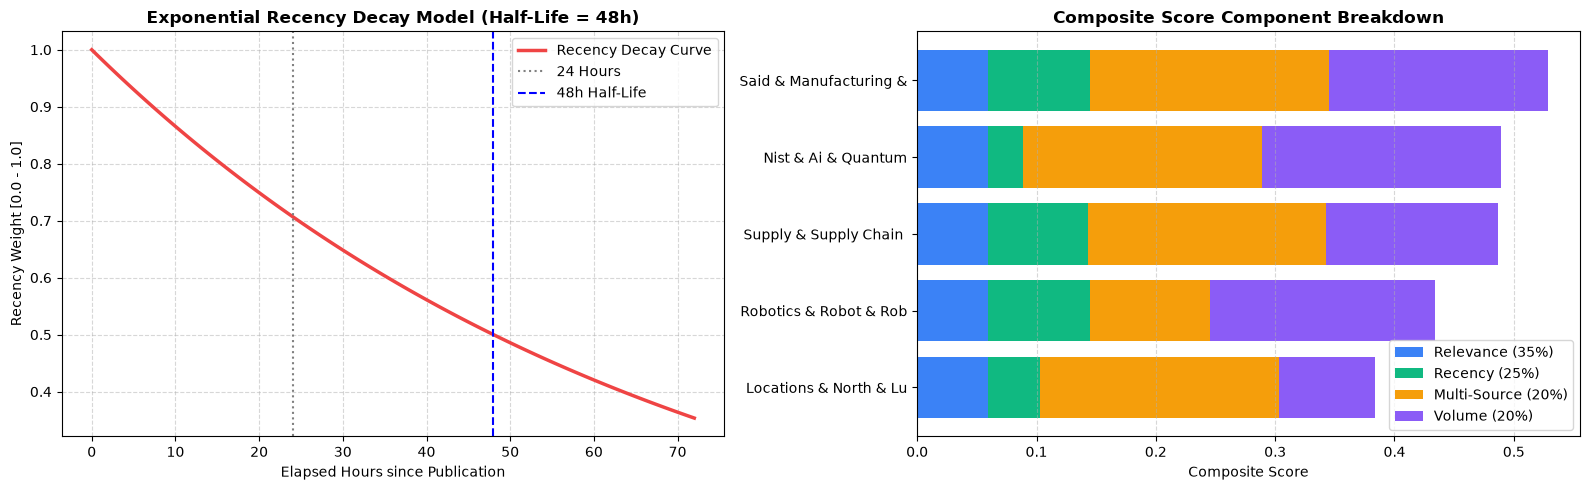

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Recency Decay Model
ax1.plot(hours_axis, decay_scores, color="#ef4444", linewidth=2.5, label="Recency Decay Curve")
ax1.axvline(24, color="gray", linestyle=":", label="24 Hours")
ax1.axvline(48, color="blue", linestyle="--", label="48h Half-Life")
ax1.set_title("Exponential Recency Decay Model (Half-Life = 48h)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Elapsed Hours since Publication")
ax1.set_ylabel("Recency Weight [0.0 - 1.0]")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Stacked Component Breakdown
ranks = df_breakdown["Theme"][::-1]
rel_vals = df_breakdown["Relevance (35%)"][::-1]
rec_vals = df_breakdown["Recency (25%)"][::-1]
multi_vals = df_breakdown["Multi-Source (20%)"][::-1]
vol_vals = df_breakdown["Volume (20%)"][::-1]

ax2.barh(ranks, rel_vals, label="Relevance (35%)", color="#3b82f6")
ax2.barh(ranks, rec_vals, left=rel_vals, label="Recency (25%)", color="#10b981")
ax2.barh(ranks, multi_vals, left=rel_vals+rec_vals, label="Multi-Source (20%)", color="#f59e0b")
ax2.barh(ranks, vol_vals, left=rel_vals+rec_vals+multi_vals, label="Volume (20%)", color="#8b5cf6")

ax2.set_title("Composite Score Component Breakdown", fontsize=12, fontweight="bold")
ax2.set_xlabel("Composite Score")
ax2.legend(loc="lower right")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



*Interpretation of Visualizations*:
1. **Recency Decay**: Smooth, predictable decay provides fair opportunity for weekend articles while favoring fresher news.
2. **Component Breakdown**: Stacked bars visually explain the exact mathematical balance between relevance, timeliness, source consensus, and volume.



### Section 8: Errors, Limitations & Assumptions
1. **Fixed Weights Assumption**: The weights (35% relevance, 25% recency, 20% multi-source, 20% volume) were selected to balance breaking stories with authoritative coverage.
2. **Publication Delay**: If a feed delays publishing an article by 12 hours, its recency score will reflect the published timestamp rather than original event occurrence.
3. **Deterministic Ranking**: By avoiding black-box LLM scoring, ranking is 100% auditable and reproducible.



### Section 9: Summary of Findings
- **Top 5 Developments**: Selected 5 distinct industrial developments representing the core signal of the current news cycle.
- **Traceable Scoring**: Every development has a fully auditable composite score.
- **Output Artifact**: Serialized to `data/processed/ranked_developments_manufacturing.json`.



### Section 10: Next Notebook's Input and Expected Output
- **Next Notebook**: `09_report_generation.ipynb`
- **Input Artifact**: `data/processed/ranked_developments_manufacturing.json`.
- **Expected Output Artifact**: Responsive one-page HTML brief (`reports/generated/daily_brief_manufacturing.html`) and email preview (`reports/previews/`).

